Length mismatch: using first 6 points.
lightshift(img_amp) = 1.925714e+05 * img_amp + -2.816190e+03  [Hz]


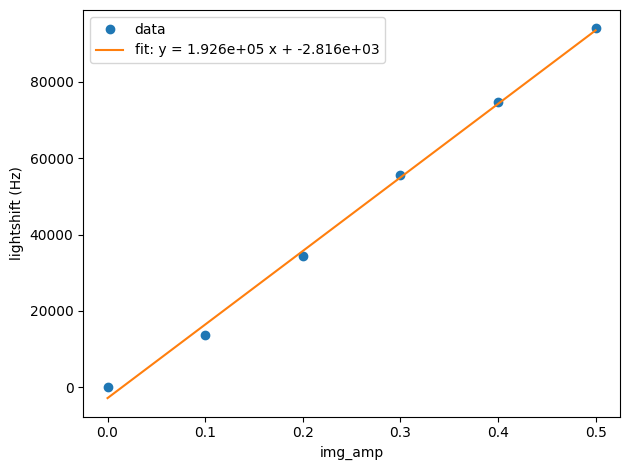

In [1]:
import numpy as np

img_amps = [0., .1, .2,.3,.4,.5,.6]
lightshifts = [0.,13.6e3,34.3e3,55.5e3,74.6e3,93.96e3]

import matplotlib.pyplot as plt

x = np.asarray(img_amps, dtype=float)
y = np.asarray(lightshifts, dtype=float)

if x.size != y.size:
    n = min(x.size, y.size)
    print(f'Length mismatch: using first {n} points.')
    x = x[:n]
    y = y[:n]

m, b = np.polyfit(x, y, 1)

def lightshift_from_img_amp(img_amp):
    return m * np.asarray(img_amp) + b

xfit = np.linspace(x.min(), x.max(), 200)
yfit = lightshift_from_img_amp(xfit)

plt.figure()
plt.plot(x, y, 'o', label='data')
plt.plot(xfit, yfit, '-', label=f'fit: y = {m:.3e} x + {b:.3e}')
plt.xlabel('img_amp')
plt.ylabel('lightshift (Hz)')
plt.legend()
plt.tight_layout()

print(f'lightshift(img_amp) = {m:.6e} * img_amp + {b:.6e}  [Hz]')

In [2]:
lightshift_from_img_amp(.2)

np.float64(35698.09523809523)

In [ ]:
img_amps = np.linspace(.2,2.5,100)

119.4641e6 + lightshift_from_img_amp(img_amps)